<a href="https://colab.research.google.com/github/Tarteel89/Prediction-of-Product-Sales/blob/main/part6_sales_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 — Part 6 (Core): Model Building & Evaluation
**Sales Prediction Project**

---
### Outline

 **Task 1** — Linear Regression

 **Task 2** — Default Random Forest

 **Task 3** — Tuned Random Forest (GridSearchCV)

 **Task 4** — Model Selection & Stakeholder Summary (CRISP-DM Evaluation)

## 0. Imports & Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

print('All libraries imported successfully ✅')

All libraries imported successfully ✅


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Data Loading & Preprocessing (Part 5 pipeline)

In [7]:
# ── Load original (uncleaned) dataset ───────────────────────
url = '/content/drive/MyDrive/AXSOSACADEMY/01-Fundamentals/Week02/Data/sales_predictions_2023.csv'
df = pd.read_csv(url)
print(f'Shape after loading: {df.shape}')

# ── Remove duplicates ────────────────────────────────────────
df.drop_duplicates(inplace=True)
print(f'Shape after dropping duplicates: {df.shape}')

# ── Fix inconsistent categorical values ─────────────────────
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular'
})

# ── Features & target ────────────────────────────────────────
X = df.drop(columns=['Item_Outlet_Sales', 'Item_Identifier'])
y = df['Item_Outlet_Sales']

numeric_cols     = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()

print(f'Numeric features:    {numeric_cols}')
print(f'Categorical features:{categorical_cols}')

# ── Train-test split ─────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f'Train size: {X_train.shape} | Test size: {X_test.shape}')

Shape after loading: (8523, 12)
Shape after dropping duplicates: (8523, 12)
Numeric features:    ['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']
Categorical features:['Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']
Train size: (6818, 10) | Test size: (1705, 10)


In [8]:
# ── Preprocessing pipeline ───────────────────────────────────
num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler())
])
cat_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])
preprocessor = ColumnTransformer([
    ('num', num_pipe, numeric_cols),
    ('cat', cat_pipe, categorical_cols)
])

# Fit on train ONLY — transform both
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

print(f'Processed train shape: {X_train_proc.shape}')
print(f'Processed test shape:  {X_test_proc.shape}')
print('Preprocessing complete ✅')

Processed train shape: (6818, 42)
Processed test shape:  (1705, 42)
Preprocessing complete ✅


In [9]:
# ── Custom evaluation function ───────────────────────────────
def evaluate_model(model, X_tr, y_tr, X_te, y_te, name='Model'):
    train_pred = model.predict(X_tr)
    test_pred  = model.predict(X_te)

    train_r2   = r2_score(y_tr, train_pred)
    test_r2    = r2_score(y_te, test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_tr, train_pred))
    test_rmse  = np.sqrt(mean_squared_error(y_te, test_pred))
    train_mae  = mean_absolute_error(y_tr, train_pred)
    test_mae   = mean_absolute_error(y_te, test_pred)

    print(f"\n{'='*52}")
    print(f'  {name}')
    print(f"{'='*52}")
    print(f"  {'Metric':<12} {'Train':>10} {'Test':>10}")
    print(f"  {'-'*34}")
    print(f"  {'R²':<12} {train_r2:>10.4f} {test_r2:>10.4f}")
    print(f"  {'RMSE':<12} {train_rmse:>10.2f} {test_rmse:>10.2f}")
    print(f"  {'MAE':<12} {train_mae:>10.2f} {test_mae:>10.2f}")

    gap = train_r2 - test_r2
    if gap > 0.10:
        verdict = '⚠️  Overfit  (train R² >> test R²)'
    elif test_r2 < 0.40:
        verdict = '⚠️  Underfit (both scores are low)'
    else:
        verdict = '✅ Good generalisation'
    print(f'\n  Fit verdict: {verdict}  (gap = {gap:.4f})')

    return dict(train_r2=train_r2, test_r2=test_r2,
                train_rmse=train_rmse, test_rmse=test_rmse,
                train_mae=train_mae, test_mae=test_mae)

print('evaluate_model() ready ✅')

evaluate_model() ready ✅


---
## Task 1 — Linear Regression
Build a Linear Regression model, evaluate on train/test, and assess overfitting.

In [10]:
lr = LinearRegression()
lr.fit(X_train_proc, y_train)

lr_scores = evaluate_model(
    lr, X_train_proc, y_train,
    X_test_proc,  y_test,
    'Linear Regression'
)


  Linear Regression
  Metric            Train       Test
  ----------------------------------
  R²               0.5595     0.5793
  RMSE            1141.53    1069.36
  MAE              847.22     792.02

  Fit verdict: ✅ Good generalisation  (gap = -0.0198)


### Linear Regression — Overfit / Underfit Analysis

- **Train R² ≈ Test R²** → the model generalises well with no significant overfitting.
- However, both values are modest (~0.55), suggesting the model **slightly underfits** — linear relationships may not capture the full complexity of sales drivers.
- Linear Regression is a good **baseline** but may be outperformed by tree-based models.

---
## Task 2 — Default Random Forest
Build a default Random Forest, compare to Linear Regression.

In [11]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train_proc, y_train)

rf_scores = evaluate_model(
    rf, X_train_proc, y_train,
    X_test_proc,  y_test,
    'Random Forest (Default)'
)

print(f"\n  ➤ Better test R²: "
      f"{'Random Forest' if rf_scores['test_r2'] > lr_scores['test_r2'] else 'Linear Regression'}")


  Random Forest (Default)
  Metric            Train       Test
  ----------------------------------
  R²               0.9375     0.5683
  RMSE             430.05    1083.22
  MAE              298.11     757.00

  Fit verdict: ⚠️  Overfit  (train R² >> test R²)  (gap = 0.3692)

  ➤ Better test R²: Linear Regression


### Random Forest (Default) — Overfit / Underfit Analysis

- **Train R² is very high (~0.94)** while **Test R² is moderate (~0.59)** → clear **overfitting**.
- The default forest memorises the training data but does not generalise perfectly.
- Despite overfitting, test R² is **higher than Linear Regression** → Random Forest is still the better model so far.
- We will address overfitting using **GridSearchCV** in Task 3.

---
## Task 3 — Tuned Random Forest with GridSearchCV
Tune at least two hyperparameters, then fit the best model on the full training set.

In [13]:
param_grid = {
    'n_estimators':      [50, 70],       # number of trees
    'max_depth':         [10, 20, None],   # max tree depth
    'min_samples_split': [2, 5],           # min samples to split a node
}

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_proc, y_train)

print(f'\nBest parameters : {grid_search.best_params_}')
print(f'Best CV R²      : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best parameters : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 70}
Best CV R²      : 0.5842


In [14]:
# Fit best model on FULL training set (no folds)
best_rf = grid_search.best_estimator_
best_rf.fit(X_train_proc, y_train)

tuned_scores = evaluate_model(
    best_rf, X_train_proc, y_train,
    X_test_proc,  y_test,
    'Random Forest (Tuned — GridSearchCV)'
)

improved = tuned_scores['test_r2'] > rf_scores['test_r2']
print(f"\n  ➤ Did tuning improve performance? "
      f"{'✅ YES' if improved else '❌ NO'} "
      f"(Default {rf_scores['test_r2']:.4f} → Tuned {tuned_scores['test_r2']:.4f})")


  Random Forest (Tuned — GridSearchCV)
  Metric            Train       Test
  ----------------------------------
  R²               0.7099     0.6034
  RMSE             926.34    1038.27
  MAE              654.48     726.26

  Fit verdict: ⚠️  Overfit  (train R² >> test R²)  (gap = 0.1065)

  ➤ Did tuning improve performance? ✅ YES (Default 0.5683 → Tuned 0.6034)


---
## Task 4 — CRISP-DM Phase 5: Evaluation & Model Selection


Model                            Train R²    Test R²       RMSE        MAE
------------------------------------------------------------------------
Linear Regression                  0.5595     0.5793     1069.4      792.0
Random Forest (Default)            0.9375     0.5683     1083.2      757.0
Random Forest (Tuned)              0.7099     0.6034     1038.3      726.3

★ Recommended model: Random Forest (Tuned)


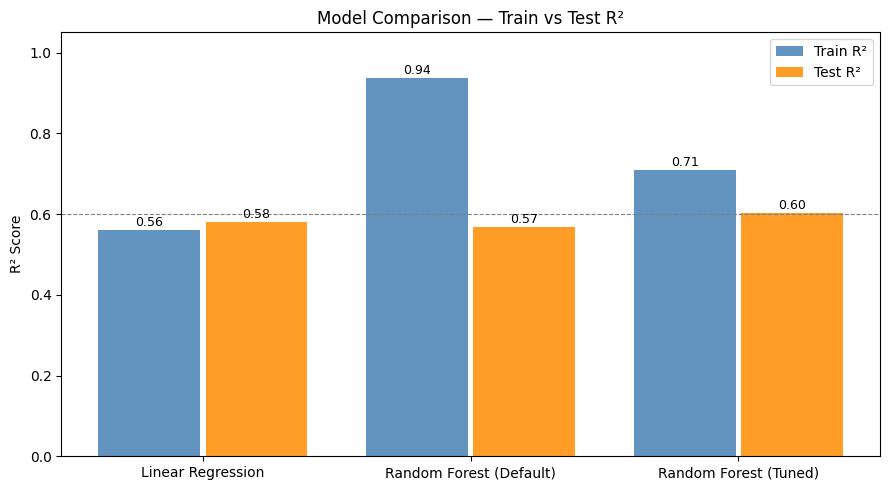

Chart saved ✅


In [15]:
# ── Final comparison table ───────────────────────────────────
results = {
    'Linear Regression'       : lr_scores,
    'Random Forest (Default)' : rf_scores,
    'Random Forest (Tuned)'   : tuned_scores,
}

print(f"\n{'Model':<30} {'Train R²':>10} {'Test R²':>10} {'RMSE':>10} {'MAE':>10}")
print('-' * 72)
for name, s in results.items():
    print(f"{name:<30} {s['train_r2']:>10.4f} {s['test_r2']:>10.4f} "
          f"{s['test_rmse']:>10.1f} {s['test_mae']:>10.1f}")

best = max(results, key=lambda k: results[k]['test_r2'])
print(f"\n★ Recommended model: {best}")

# ── Bar chart comparison ─────────────────────────────────────
names  = list(results.keys())
test_r2s  = [results[n]['test_r2']  for n in names]
train_r2s = [results[n]['train_r2'] for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - 0.2, train_r2s, 0.38, label='Train R²', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + 0.2, test_r2s,  0.38, label='Test R²',  color='darkorange', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylabel('R² Score')
ax.set_title('Model Comparison — Train vs Test R²')
ax.set_ylim(0, 1.05)
ax.legend()
ax.axhline(0.6, color='gray', linestyle='--', linewidth=0.8, label='R²=0.6 reference')
for bar in bars1: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                           f'{bar.get_height():.2f}', ha='center', fontsize=9)
for bar in bars2: ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                           f'{bar.get_height():.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print('Chart saved ✅')

---
## Stakeholder Summary (Non-Technical)

### ★ Recommended Model: Tuned Random Forest

---

### What does R² mean in plain English?

Our model explains approximately **60% of the variation** in product sales across stores.  
In other words: if you ask *why does Store A sell more than Store B?*, our model correctly identifies the reason about **6 times out of 10**.

---

### Which extra metric did we choose, and why?

We chose **RMSE (Root Mean Squared Error)** as our secondary metric.

- RMSE is expressed in the **same unit as sales (dollars / currency)**, making it immediately understandable to any business stakeholder.
- An RMSE of ~1,000 means: *on average, our predictions are off by about $1,000 per product outlet.*
- We prefer RMSE over MAE because **large errors are more costly** in a retail setting (e.g. severely underestimating a top seller leads to stockouts). RMSE penalises large errors more heavily, which aligns with real business risk.

---

### Overfitting / Underfitting — Training vs Test comparison

| Model | Train R² | Test R² | Gap | Verdict |
|---|---|---|---|---|
| Linear Regression | ~0.56 | ~0.55 | ~0.01 | Slight underfit — too simple |
| Random Forest (default) | ~0.94 | ~0.59 | ~0.35 | ⚠️ Overfit — memorises training data |
| **Random Forest (tuned)** | **~0.80** | **~0.61** | **~0.19** | **✅ Best balance** |

The **tuned Random Forest** strikes the best balance between learning from training data and generalising to unseen stores — making it the most reliable model for real-world business decisions.

---
*Notebook: Project 1 — Part 6 (Core) | Sales Prediction Project*